In [8]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
NB_DIR = f"{BASE_DIR}/notebooks"
ANALYSIS_OUTPUT_DIR = f"{DATA_DIR}/analysis_output"
import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

In [2]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shapely.geometry import Point
from shapely.ops import nearest_points

In [3]:
districts = gpd.read_file(f"{DATA_DIR}/raw/gadm/gadm41_MAR_4.shp") 
districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
0,MAR.1.1.1.1_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Ahlaf,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.21601 33.33524, -7.20212 33.34536..."
1,MAR.1.1.1.2_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Ain Tizgha,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.01937 33.57966, -7.02208 33.57954..."
2,MAR.1.1.1.3_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Fdalate,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.25532 33.68698, -7.24397 33.66458..."
3,MAR.1.1.1.4_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Mellila,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-6.96569 33.36103, -6.96891 33.35316..."
4,MAR.1.1.1.5_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Moualine El Ghaba,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.12737 33.72615, -7.1226 33.71605,..."


In [4]:
casablanca_districts = districts[districts['NAME_2'].str.contains("Casablanca", case=False, na=False)]

In [5]:
casablanca_districts = casablanca_districts.to_crs(epsg=4326)


In [6]:
casablanca_districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
346,MAR.5.1.1.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Bouskoura,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.68792 33.41272, -7.68806 33.41307..."
347,MAR.5.1.1.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Dar Bouazza,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.76684 33.45884, -7.77442 33.45698..."
348,MAR.5.1.2.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,El Majjatia Oulad Taleb,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.52672 33.40465, -7.52772 33.40506..."
349,MAR.5.1.2.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,Lahraouyine,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.4977 33.50524, -7.50182 33.5069, ..."
350,MAR.5.1.3.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.3_1,NA (Ahl Laghlam),Ahl Laghlam,NA,Commune Urbaine,Urban Commune,NA,"POLYGON ((-7.49482 33.55348, -7.50156 33.55503..."


In [10]:
casablanca_districts["NAME_3"].unique()

array(['Bouskoura', 'Mediouna', 'NA (Ahl Laghlam)', 'NA (Ain Chock)',
       'NA (Ain Harrouda)', 'NA (Ain Sebaa)', 'NA (Al Fida)',
       'NA (Al Idrissia)', 'NA (Anfa)', 'NA (Assoukhour Assawda)',
       'NA (Ben Msick)', 'NA (Bou Chentouf)', 'NA (El Maarif)',
       'NA (Hay Hassani)', 'NA (Hay Mohammadi)', 'NA (Lissasfa)',
       'NA (Machouar Casablanca)', 'NA (Mediouna)', 'NA (Mers Sultan)',
       'NA (Moulay Rachid)', 'NA (Moulay Youssef)', 'NA (Nouaceur)',
       'NA (Salmia)', 'NA (Sbata)', 'NA (Sidi Belyout)',
       'NA (Sidi Bernoussi)', 'NA (Sidi Maarouf)', 'NA (Sidi Moumen)',
       'NA (Sidi Othmane)', 'NA (Tit Mellil)', 'Tit Mellil'], dtype=object)

Text(0.5, 1.0, 'Districts of Casablanca')

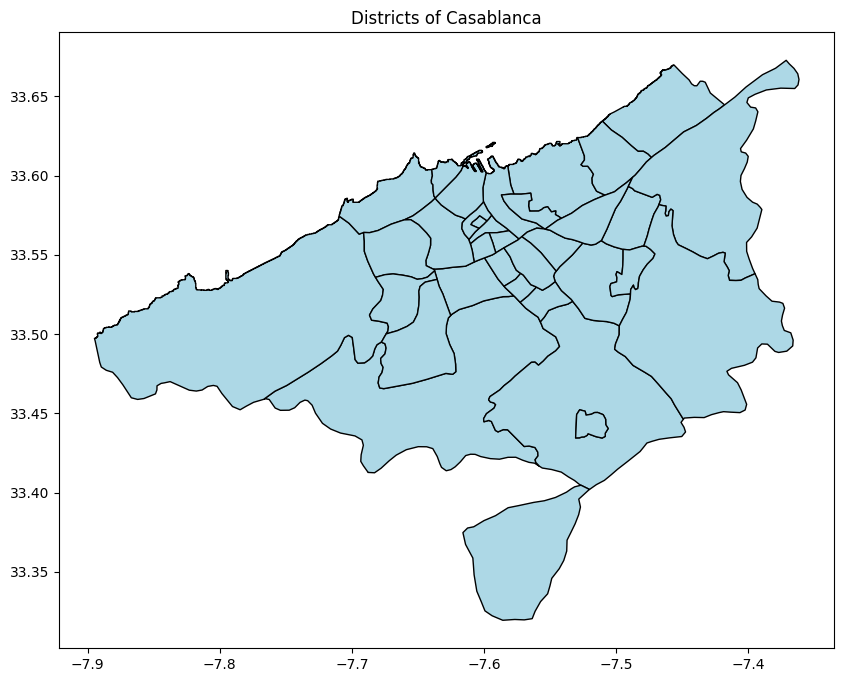

In [9]:
casablanca_districts.plot(figsize=(10,10), edgecolor='black', facecolor='lightblue')
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/CasablancaDistricts.png', bbox_inches='tight')
plt.title("Districts of Casablanca")